In [53]:
import json
import base64
import qrcode
import requests
import datetime
import uuid
import matplotlib.pyplot as plt
from IPython import display
from pymongo import MongoClient
from typing import Optional, List
from didcomm.common.types import DID, VerificationMethodType, VerificationMaterial, VerificationMaterialFormat
from didcomm.did_doc.did_doc import DIDDoc, VerificationMethod, DIDCommService
from didcomm.did_doc.did_resolver import DIDResolver
from didcomm.message import Message, FromPrior
from didcomm.secrets.secrets_resolver_demo import SecretsResolverDemo
from didcomm.unpack import unpack, UnpackResult
from didcomm.common.resolvers import ResolversConfig
from didcomm.pack_encrypted import pack_encrypted, PackEncryptedConfig, PackEncryptedResult
from peerdid.core.did_doc_types import DIDCommServicePeerDID
from didcomm.secrets.secrets_util import generate_x25519_keys_as_jwk_dict, generate_ed25519_keys_as_jwk_dict, jwk_to_secret
from peerdid import peer_did
from peerdid.did_doc import DIDDocPeerDID
from peerdid.types import VerificationMaterialAuthentication, VerificationMethodTypeAuthentication, VerificationMaterialAgreement, VerificationMethodTypeAgreement, VerificationMaterialFormatPeerDID

In [54]:
secrets_resolver = SecretsResolverDemo()

In [55]:
class DIDResolverPeerDID(DIDResolver):
    async def resolve(self, did: DID) -> DIDDoc:
        did_doc_json = peer_did.resolve_peer_did(did, format=VerificationMaterialFormatPeerDID.JWK)
        did_doc = DIDDocPeerDID.from_json(did_doc_json)

        return DIDDoc(
            did=did_doc.did,
            key_agreement_kids=did_doc.agreement_kids,
            authentication_kids=did_doc.auth_kids,
            verification_methods=[
                VerificationMethod(
                    id=m.id,
                    type=VerificationMethodType.JSON_WEB_KEY_2020,
                    controller=m.controller,
                    verification_material=VerificationMaterial(
                        format=VerificationMaterialFormat.JWK,
                        value=json.dumps(m.ver_material.value)  # Ensure correct serialization
                    )
                )
                for m in did_doc.authentication + did_doc.key_agreement
            ],
            didcomm_services=[
                DIDCommService(
                    id=s.id,
                    service_endpoint=s.service_endpoint.get("uri") if isinstance(s.service_endpoint, dict) else s.service_endpoint,
                    recipient_keys=s.recipient_keys if hasattr(s, "recipient_keys") else [],
                    routing_keys=s.service_endpoint.get("routingKeys", []) if isinstance(s.service_endpoint, dict) else [],
                    accept=s.service_endpoint.get("accept", []) if isinstance(s.service_endpoint, dict) else []

                )
                for s in did_doc.service
                if isinstance(s, DIDCommServicePeerDID)
            ] if did_doc.service else []
        )


In [56]:
async def create_peer_did(self,
                          auth_keys_count: int = 1,
                          agreement_keys_count: int = 1,
                          service_endpoint: [str] = None,
                          service_routing_keys: [List[str]] = None
                          ) -> str:
    # 1. Generate keys in JWK format
    agreem_keys = [generate_x25519_keys_as_jwk_dict() for _ in range(agreement_keys_count)]
    auth_keys = [generate_ed25519_keys_as_jwk_dict() for _ in range(auth_keys_count)]

    # 2. Prepare the keys for peer DID lib
    agreem_keys_peer_did = [
        VerificationMaterialAgreement(
            type=VerificationMethodTypeAgreement.JSON_WEB_KEY_2020,
            format=VerificationMaterialFormatPeerDID.JWK,
            value=k[1],
        )
        for k in agreem_keys
    ]
    auth_keys_peer_did = [
        VerificationMaterialAuthentication(
            type=VerificationMethodTypeAuthentication.JSON_WEB_KEY_2020,
            format=VerificationMaterialFormatPeerDID.JWK,
            value=k[1],
        )
        for k in auth_keys
    ]

    # 3. Generate service
    service = None
    if service_endpoint:
        service_data = {
            "id": "#didcomm",
            "type": "DIDCommMessaging",
            "serviceEndpoint": {
                "uri": "http://localhost:8000",
                "routingKeys": [],
                "accept": ["didcomm/v2"]
            },
        }
        if service_routing_keys:
            service_data["routingKeys"] = service_routing_keys

        service = json.dumps(service_data)

# 4. call peer DID lib
        # if we have just one key (auth), then use numalg0 algorithm
        # otherwise use numalg2 algorithm
        if len(auth_keys_peer_did) == 1 and not agreem_keys_peer_did and not service:
            did = peer_did.create_peer_did_numalgo_0(auth_keys_peer_did[0])
        else:
            did = peer_did.create_peer_did_numalgo_2(
                encryption_keys=agreem_keys_peer_did,
                signing_keys=auth_keys_peer_did,
                service=service,
            )

        # 5. set KIDs as in DID DOC for secrets and store the secret in the secrets resolver
        did_doc = DIDDocPeerDID.from_json(peer_did.resolve_peer_did(did))
        for auth_key, kid in zip(auth_keys, did_doc.auth_kids):
            private_key = auth_key[0]
            private_key["kid"] = kid
            await secrets_resolver.add_key(jwk_to_secret(private_key))

        for agreem_key, kid in zip(agreem_keys, did_doc.agreement_kids):
            private_key = agreem_key[0]
            private_key["kid"] = kid
            await secrets_resolver.add_key(jwk_to_secret(private_key))

        return did


### Alice get OOB from Mediator

In [57]:
#oob_url = requests.get("http://127.0.0.1:8000/oob_url").text
oob_url = requests.get("http://localhost:8080/oob_url").text

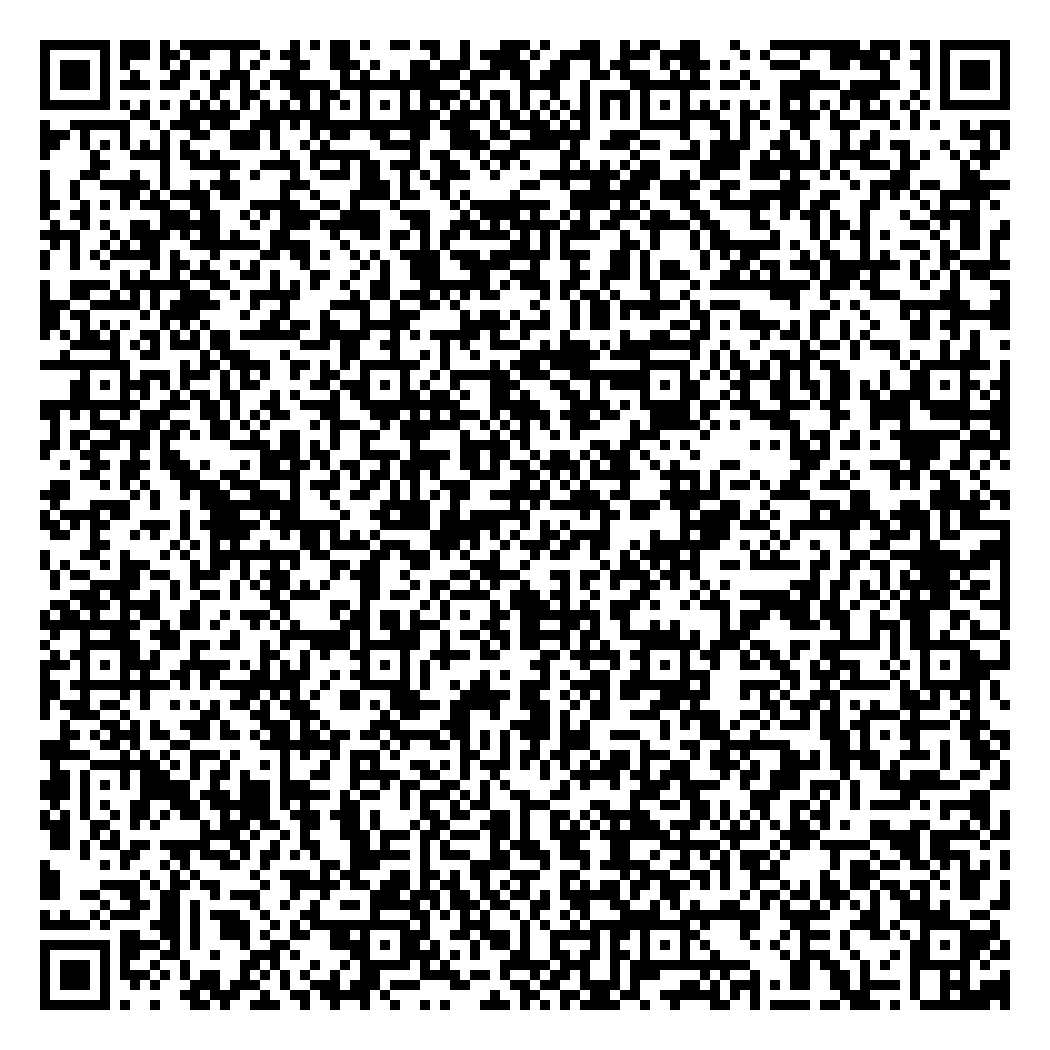

In [58]:
im = qrcode.make(oob_url)
im.save('qr.png')
display.Image('qr.png',width=500,height=500)

In [59]:
received_msg_encoded = oob_url.split("=")[1]
received_msg_decoded = json.loads(str(base64.urlsafe_b64decode(received_msg_encoded + "=="), "utf-8"))
alice_did_for_mediator = await create_peer_did(1,1,1,1)
print("Alice's DID:", alice_did_for_mediator)

Alice's DID: did:peer:2.Ez6LSsuXPn94cLxCG1kAwvWU4RHLNH16X7mWj2XMpGQ9Nj4oG.Vz6MkediAHG9vnqTZmXWwr4MaiUra6PAJMgZwuw4zLaVGygZ7.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJ1cmkiOiJodHRwOi8vbG9jYWxob3N0OjgwMDAiLCJyIjpbXSwiYSI6WyJkaWRjb21tL3YyIl19fQ


### Alice request mediate

In [60]:
alice_mediate_grant = Message(
    custom_headers = {"return_route": "all"},
    id = str(uuid.uuid4()),
    type = "https://didcomm.org/coordinate-mediation/2.0/mediate-request",
    frm = alice_did_for_mediator,
    body = {}
)

In [61]:
alice_mediate_grant_packed = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_mediate_grant,
    frm = alice_did_for_mediator,
    to = received_msg_decoded["from"],
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
print(alice_mediate_grant_packed)

ValidationError: 1 validation error for DIDDoc
id
  field required (type=value_error.missing)

### Sending to Mediator

In [62]:
mediator_did_doc = json.loads(peer_did.resolve_peer_did(received_msg_decoded["from"]))
mediator_endpoint = mediator_did_doc["service"][0]["serviceEndpoint"]["uri"]
print(mediator_endpoint)

http://localhost:8080


In [63]:
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp = requests.post(mediator_endpoint, headers=headers, json = json.loads(alice_mediate_grant_packed.packed_msg))


NameError: name 'alice_mediate_grant_packed' is not defined

In [391]:
print(resp.json())

{'error': 'Could not unpack message'}


### Get mediator grant response

In [124]:
mediator_unpack_msg = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp.json()
)
print(mediator_unpack_msg.message.type)
print("Routing Key: " + mediator_unpack_msg.message.body["routing_did"])
print("Mediator new DID: " + mediator_unpack_msg.message.frm)
# mediator rotated did
mediator_routing_key = mediator_unpack_msg.message.body["routing_did"]
mediator_did = mediator_unpack_msg.message.frm

https://didcomm.org/coordinate-mediation/2.0/mediate-grant
Routing Key: did:peer:2.Vz6MkrWYhdXQRqjUWMH3y4SQZoKybVMePErwQMQYzyHY6xaum.Ez6LSnArQL8DPh2ow3cXpruu22EGWkKKwWExe3dh1HGLBXvWQ.SeyJpZCI6IiNkaWRjb21tIiwicyI6eyJhIjpbImRpZGNvbW0vdjIiXSwiciI6W10sInVyaSI6Imh0dHA6Ly9sb2NhbGhvc3Q6ODA4MCJ9LCJ0IjoiZG0ifQ
Mediator new DID: did:peer:2.Vz6MkhqCaszhTVhFjEML6Y7kNh4BfDLUWQxXxwekTFAgLpL68.Ez6LSi1UU6ZiZHQVTjdFTWAydnUadjsqrcnyawqKS9tpxnZK6.SeyJpZCI6IiNkaWRjb21tIiwicyI6eyJhIjpbImRpZGNvbW0vdjIiXSwiciI6W10sInVyaSI6Imh0dHA6Ly9sb2NhbGhvc3Q6ODA4MCJ9LCJ0IjoiZG0ifQ


### Keylist update

Alice create a new DID to share with  other peers using mediator routing keys 

In [125]:
#alice_did_new = await create_peer_did(1, 1, service_endpoint=mediator_endpoint, service_routing_keys=[mediator_routing_key])
alice_did_for_bob = await create_peer_did(1, 1, service_endpoint=[{"uri": mediator_routing_key}])

print("Alice's DID for Bob:", alice_did_for_bob)

Alice's DID for Bob: did:peer:2.Ez6LSbyMVq9Rivvdt3S8cij1UXSf2REhHPL5ARrEPziht1E7U.Vz6MkqbZnxHtegqD6tFwjprvrWi1sRU62zymUHMND8ysQzDkk.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJhIjpbImRpZGNvbW0vdjIiXSwiciI6W10sInVyaSI6Imh0dHA6Ly9sb2NhbGhvc3Q6ODA4MCJ9fQ


Alice create and send the keylist update message

In [126]:
alice_keylist_update = Message(
    id = "unique-id-293e9a922efff",
    type = "https://didcomm.org/coordinate-mediation/2.0/keylist-update",
    frm = alice_did_for_mediator,
    body = {
        "updates":[
        {
            "recipient_did": alice_did_for_bob,
            "action": "add"
        }
    ]
    }
)

In [127]:
alice_keylist_update_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_keylist_update,
    frm = alice_did_for_mediator,
    to = mediator_did,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)

In [128]:
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp = requests.post(mediator_endpoint, headers=headers, data = alice_keylist_update_packed_msg.packed_msg)

In [129]:
print(resp.json())

{'protected': 'eyJ0eXAiOiJhcHBsaWNhdGlvbi9kaWRjb21tLWVuY3J5cHRlZCtqc29uIiwiYWxnIjoiRUNESC0xUFUrQTI1NktXIiwiZW5jIjoiQTI1NkNCQy1IUzUxMiIsInNraWQiOiJkaWQ6cGVlcjoyLlZ6Nk1raHFDYXN6aFRWaEZqRU1MNlk3a05oNEJmRExVV1F4WHh3ZWtURkFnTHBMNjguRXo2TFNpMVVVNlppWkhRVlRqZEZUV0F5ZG5VYWRqc3FyY255YXdxS1M5dHB4blpLNi5TZXlKcFpDSTZJaU5rYVdSamIyMXRJaXdpY3lJNmV5SmhJanBiSW1ScFpHTnZiVzB2ZGpJaVhTd2ljaUk2VzEwc0luVnlhU0k2SW1oMGRIQTZMeTlzYjJOaGJHaHZjM1E2T0RBNE1DSjlMQ0owSWpvaVpHMGlmUSM2TFNpMVVVNlppWkhRVlRqZEZUV0F5ZG5VYWRqc3FyY255YXdxS1M5dHB4blpLNiIsImFwdSI6IlpHbGtPbkJsWlhJNk1pNVdlalpOYTJoeFEyRnplbWhVVm1oR2FrVk5URFpaTjJ0T2FEUkNaa1JNVlZkUmVGaDRkMlZyVkVaQloweHdURFk0TGtWNk5reFRhVEZWVlRaYWFWcElVVlpVYW1SR1ZGZEJlV1J1VldGa2FuTnhjbU51ZVdGM2NVdFRPWFJ3ZUc1YVN6WXVVMlY1U25CYVEwazJTV2xPYTJGWFVtcGlNakYwU1dsM2FXTjVTVFpsZVVwb1NXcHdZa2x0VW5CYVIwNTJZbGN3ZG1ScVNXbFlVM2RwWTJsSk5sY3hNSE5KYmxaNVlWTkpOa2x0YURCa1NFRTJUSGs1YzJJeVRtaGlSMmgyWXpOUk5rOUVRVFJOUTBvNVRFTktNRWxxYjJsYVJ6QnBabEVqTmt4VGFURlZWVFphYVZwSVVWWlVhbVJHVkZkQmVXUnVWV0ZrYW5OeGNtTnVlV

In [130]:
mediator_unpack_msg2 = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp.json()
)
print(mediator_unpack_msg2.message.type)
print(mediator_unpack_msg2.message.body)


https://didcomm.org/coordinate-mediation/2.0/keylist-update-response
{'updated': [{'recipient_did': 'did:peer:2.Ez6LSbyMVq9Rivvdt3S8cij1UXSf2REhHPL5ARrEPziht1E7U.Vz6MkqbZnxHtegqD6tFwjprvrWi1sRU62zymUHMND8ysQzDkk.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJhIjpbImRpZGNvbW0vdjIiXSwiciI6W10sInVyaSI6Imh0dHA6Ly9sb2NhbGhvc3Q6ODA4MCJ9fQ', 'action': 'add', 'result': 'success'}]}


### Alice can now send her DID to Bob. Copy Alice's DID into Bob's notebook, and follows Bob's notebook

In [133]:
print(alice_did_for_bob)

did:peer:2.Ez6LSbyMVq9Rivvdt3S8cij1UXSf2REhHPL5ARrEPziht1E7U.Vz6MkqbZnxHtegqD6tFwjprvrWi1sRU62zymUHMND8ysQzDkk.SeyJpZCI6IiNkaWRjb21tIiwidCI6ImRtIiwicyI6eyJhIjpbImRpZGNvbW0vdjIiXSwiciI6W10sInVyaSI6Imh0dHA6Ly9sb2NhbGhvc3Q6ODA4MCJ9fQ


### Alice check status of queued messages from the Mediator

In [134]:
alice_status_check = Message(
    id = "unique-id-293e9a922efffxxx",
    type = "https://didcomm.org/messagepickup/3.0/status-request",
    body = {}
)

In [135]:
alice_status_check_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_status_check,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp3 = requests.post(mediator_endpoint, headers=headers, data = alice_status_check_packed_msg.packed_msg)

In [136]:
mediator_unpack_status = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp3.json()
)
print(mediator_unpack_status.message.type)
print("Messages in Mediator queue: " + str(mediator_unpack_status.message.body["message_count"]))

MalformedMessageError: MalformedMessageCode.INVALID_PLAINTEXT

### If there are messages, Alice can pickup from the mediator (delivery request)

In [ ]:
alice_delivery_request = Message(
    id = "unique-id-293e9a922efffxxxff",
    type = "https://didcomm.org/messagepickup/3.0/delivery-request",
    body = {"limit": 1}
)

In [ ]:
alice_delivery_request_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_delivery_request,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp4 = requests.post(mediator_endpoint, headers=headers, data = alice_delivery_request_packed_msg.packed_msg)

In [ ]:
mediator_delivery = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp4.json()
)
print(mediator_delivery.message.type)
print(mediator_delivery.message.body)

In [ ]:
bob_packed_msg = mediator_delivery.message.attachments[0].data.json
msg_id = mediator_delivery.message.attachments[0].id

In [ ]:
print(bob_packed_msg)

In [ ]:
bob_msg = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= bob_packed_msg
)

In [ ]:
print("Message ID:", msg_id)
print(bob_msg.message.body["content"])

### Alice acknowledge so the mediator can delete the message

In [ ]:
alice_ack = Message(
    id = "unique-id-293e9a922efffxxxffsss",
    type = "https://didcomm.org/messagepickup/3.0/messages-received",
    body = {"message_id_list": [msg_id]}
)

In [ ]:
alice_ack_packed_msg = await pack_encrypted(
    resolvers_config = ResolversConfig(
        secrets_resolver = secrets_resolver,
        did_resolver = DIDResolverPeerDID()
    ),
    message = alice_ack,
    to = mediator_did,
    frm = alice_did_for_mediator,
    sign_frm = None,
    pack_config = PackEncryptedConfig(protect_sender_id=False)
)
headers = {"Content-Type": "application/didcomm-encrypted+json"}
resp5 = requests.post(mediator_endpoint, headers=headers, data = alice_ack_packed_msg.packed_msg)

In [ ]:
mediator_ack_status = await unpack(
    resolvers_config=ResolversConfig(
        secrets_resolver=secrets_resolver,
        did_resolver=DIDResolverPeerDID()
    ),
    packed_msg= resp5.json()
)
print(mediator_ack_status.message.type)
print(mediator_ack_status.message.body)